# 🏔️ Strava Leaderboard Fraud Detection - Snowflake Native

## *Snowflake ML Platform Demo*

### **Use Case**: Leaderboard Fraud Detection
Detecting fraudulent athlete activities using Snowflake's complete ML platform - Feature Store, Model Registry, and Cortex AI.

### **Business Value**:
- **Integrity**: Maintain leaderboard trust and fair competition
- **Platform**: Centralized ML infrastructure for consistency 
- **Scale**: Real-time fraud detection across millions of activities

### **What This Demo Shows**:
- ✅ **Feature Store**: Centralized feature management eliminating duplicate engineering
- ✅ **Model Registry**: Version-controlled model lifecycle management  
- ✅ **Cortex Integration**: AI-powered analysis complementing ML
- ✅ **Real-time Scoring**: Deploy models for immediate business impact

### **Prerequisites**:
1. Environment setup completed (`01_env_setup.sql`)
2. Sample data loaded (`02_generate_and_load_data_snowflake_native.ipynb`)
3. Running in **Snowflake Notebooks**
4. **Packages installed**: Use package selector to add:
   - `snowflake-ml-python`
   - `matplotlib` (for visualizations)

*This addresses Strava's key challenges: feature consistency, model versioning, and platformization.*


## 1. Setup and Data Exploration

- Set our environment 
- Import required Snowflake ML packages.

In [1]:
# 🏔️ Setup for Snowflake ML Platform
print("🏔️ Initializing Snowflake ML Platform...")

# Import required libraries (installed via package selector)
import snowflake.snowpark as snowpark
from snowflake.ml.feature_store import FeatureStore, CreationMode, Entity, FeatureView
from snowflake.ml.modeling.ensemble import RandomForestClassifier
from snowflake.ml.registry import Registry
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Get Snowflake session (works in both Snowflake Notebooks and locally in Cursor)
try:
    from snowflake.snowpark.context import get_active_session
    session = get_active_session()
    print("✅ Running in Snowflake Notebooks")
except:
    from snowflake_connection import get_local_session
    session = get_local_session()
    print("✅ Running locally in Cursor")

print("✅ Connected to Snowflake ML Platform")
print(f"🏢 Account: {session.get_current_account()}")
print(f"👤 User: {session.get_current_user()}")
print(f"🏗️ Warehouse: {session.get_current_warehouse()}")
print(f"🗃️ Database: {session.get_current_database()}")
print(f"📁 Schema: {session.get_current_schema()}")

# Switch to demo database and schema
session.use_database("STRAVA_DEMO_SAMPLE")
session.use_schema("RAW_DATA")

print(f"🎯 Working with {session.get_current_database()}.{session.get_current_schema()}")
print("="*60)


🏔️ Initializing Snowflake ML Platform...
✅ Connected to Snowflake (Local)
🏢 Account: "SFSENORTHAMERICA-ARYEUNG_AWS1"
👤 User: "aryeung"
🏗️ Warehouse: "STRAVA_DEMO_WH"
🗃️ Database: "STRAVA_DEMO_SAMPLE"
📁 Schema: "STRAVA_MODEL_REGISTRY"
✅ Running locally in Cursor
✅ Connected to Snowflake ML Platform
🏢 Account: "SFSENORTHAMERICA-ARYEUNG_AWS1"
👤 User: "aryeung"
🏗️ Warehouse: "STRAVA_DEMO_WH"
🗃️ Database: "STRAVA_DEMO_SAMPLE"
📁 Schema: "STRAVA_MODEL_REGISTRY"
🎯 Working with "STRAVA_DEMO_SAMPLE"."RAW_DATA"


## 1.1 Sample Data
**Our demo Strava data contains 3 tables with ~ 10,000 rows each to mirror real world Strava scenario**

The data includes:
- **Activities table**: Running, cycling, and other activity data with metrics like distance, pace, heart rate, and elevation
- **Subscriptions table**: User subscription plans and engagement data
- **Challenges table**: Sponsored challenge participation and completion data

We'll use these to build our fraud detection features.

In [5]:
SELECT 'ACTIVITIES' as table_name, COUNT(*) as row_count FROM STRAVA_DEMO_SAMPLE.RAW_DATA.ACTIVITIES
UNION ALL
SELECT 'SUBSCRIPTIONS' as table_name, COUNT(*) as row_count FROM STRAVA_DEMO_SAMPLE.RAW_DATA.SUBSCRIPTIONS
UNION ALL
SELECT 'CHALLENGES' as table_name, COUNT(*) as row_count FROM STRAVA_DEMO_SAMPLE.RAW_DATA.CHALLENGES 

SyntaxError: invalid syntax (2090423167.py, line 1)

## 1.2 Understand the patterns

Looking at the activities data to understand the patterns we're working with. This query will show us the distribution of different activity types and their performance characteristics.

This is crucial for fraud detection because we need to understand what 'normal' looks like before we can identify what's suspicious. You'll see we have running, cycling, and other activities with realistic performance metrics.

The key insight here is that fraudulent activities usually show unrealistic patterns - like impossibly fast paces, inconsistent performance, or sudden dramatic improvements. These are exactly the kinds of patterns we can detect with ML.


In [ ]:
SELECT 
    activity_type,
    COUNT(*) as activity_count,
    AVG(distance_meters) as avg_distance,
    AVG(moving_time_sec) as avg_moving_time,
    AVG(total_elevation_gain_meters) as avg_elevation_gain,
    AVG(average_heartrate) as avg_heartrate
FROM STRAVA_DEMO_SAMPLE.RAW_DATA.ACTIVITIES
GROUP BY activity_type
ORDER BY activity_count DESC

🔍 Analyzing activity patterns...
---------------------------------------------------------------------------------------------------------------------------
|"ACTIVITY_TYPE"  |"ACTIVITY_COUNT"  |"AVG_DISTANCE"      |"AVG_MOVING_TIME"  |"AVG_ELEVATION_GAIN"  |"AVG_HEARTRATE"     |
---------------------------------------------------------------------------------------------------------------------------
|Run              |4929              |11665.931265976871  |3306.354839        |117.83106106715358    |144.16518563603165  |
|Ride             |3055              |55503.358232405895  |8016.109002        |1391.9174140752864    |148.66873977086743  |
|Walk             |1532              |5502.636638381201   |3544.417755        |54.990013054830285    |147.4039817232376   |
|Swim             |484               |2648.407210743802   |2544.869835        |0.0                   |147.37190082644628  |
---------------------------------------------------------------------------------------------------

## 1.3 Feature Store
Create the Feature Store using Snowflake's ML SDK. This gives us a centralized place to store and manage all our features.

As we build this together, you'll see how it automatically connects to your existing Snowflake environment - no complex setup required.

In [ ]:
# Create Feature Store using Snowflake ML SDK 
fs = FeatureStore(
    session=session,
    database="STRAVA_DEMO_SAMPLE",
    name="STRAVA_FEATURE_STORE",
    default_warehouse="STRAVA_DEMO_WH",
    creation_mode=CreationMode.CREATE_IF_NOT_EXIST,
)

print("✅ Feature Store Schema created successfully!")

# List all schemas and filter for feature stores
all_schemas = session.sql("""
    SELECT 
        CATALOG_NAME as DATABASE,
        SCHEMA_NAME as SCHEMA,
        SCHEMA_OWNER as OWNER,
        CREATED as CREATED_DATE
    FROM INFORMATION_SCHEMA.SCHEMATA 
    WHERE CATALOG_NAME = 'STRAVA_DEMO_SAMPLE'
    AND SCHEMA_NAME LIKE '%STRAVA_FEATURE%'
    ORDER BY CREATED DESC
""").collect()

for row in all_schemas:
    print(f"  - {row['DATABASE']}.{row['SCHEMA']} (Owner: {row['OWNER']})")

✅ Feature Store Schema created successfully!
  - STRAVA_DEMO_SAMPLE.STRAVA_FEATURE_STORE (Owner: STRAVA_DEMO_ADMIN)


## 1.4 Feature Table
To set up the foundation for our feature store, we'll need to create an entity for athletes - that's the core object that our features will be associated with.

As we build this together, you'll see we're defining:
- *Entity name*:  "athlete" - the main entity type
- *Join keys*:  "athlete_id" - how we'll link features to specific athletes

Next, we're creating the feature table structure using SQL. This is where we'll store all our calculated features for fraud detection. We're organizing the features into logical groups:
- *Activity-based features*:  Total activities, distances, paces
- *Performance features*:  Heart rate, elevation data
- *Challenge engagement*:  Participation metrics
- *Fraud indicators*:  Flags for suspicious patterns

This gives us a solid foundation to build our fraud detection features on.

In [ ]:
# Create Entity for athletes
athlete_entity = Entity(
    name="athlete",
    join_keys=["athlete_id"]
)

# Register the entity
fs.register_entity(athlete_entity)
print("✅ Athlete entity registered!")


# List all entities to verify
print("\n📋 Listing all entities...")
try:
    entities_df = fs.list_entities()
    
    # Check if DataFrame has any rows (Snowpark)
    if entities_df.count() > 0:
        print("✅ Found entities:")
        entities_df.show()
    else:
        print("📋 No entities found in the feature store")
        
except Exception as e:
    print(f"❌ Error listing entities: {str(e)}")


# Create Feature Table
# Note: is_fraudulent is NUMBER(1,0) instead of BOOLEAN for Model Monitor compatibility
session.sql("""
CREATE OR REPLACE TABLE STRAVA_DEMO_SAMPLE.STRAVA_FEATURE_STORE.athlete_features (
    athlete_id NUMBER(38,0),
    feature_timestamp TIMESTAMP_NTZ,
    total_activities_30d NUMBER(38,0),
    avg_pace_30d FLOAT,
    avg_heartrate_30d FLOAT,
    is_fraudulent NUMBER(1,0)
)
""").collect()

print("✅ Feature table created!")


✅ Athlete entity registered!

📋 Listing all entities...
✅ Found entities:
---------------------------------------------------------
|"NAME"   |"JOIN_KEYS"     |"DESC"  |"OWNER"            |
---------------------------------------------------------
|ATHLETE  |["ATHLETE_ID"]  |        |STRAVA_DEMO_ADMIN  |
---------------------------------------------------------

✅ Feature table created!


In [ ]:
# Session cleanup and configuration for ML training
print("🔧 Preparing session for ML training...")

try:
    # First, clean up any problematic temporary stages
    print("🧹 Cleaning up temporary stages...")
    temp_stages = session.sql("SHOW STAGES LIKE 'SNOWPARK_TEMP_STAGE_%'").collect()
    
    for stage in temp_stages:
        try:
            stage_name = stage['name']
            session.sql(f"DROP STAGE IF EXISTS {stage_name}").collect()
            print(f"   Dropped temporary stage: {stage_name}")
        except:
            pass  # Ignore errors when dropping stages
    
    # Configure session for ML operations
    session.sql("USE SCHEMA STRAVA_MODEL_REGISTRY").collect()
    
    # Verify our persistent stage exists
    stage_info = session.sql("DESC STAGE ML_STAGE").collect()
    print("✅ Persistent ML stage verified: ML_STAGE")
    
    # Reset session state to clear any cached stage references
    session.sql("ALTER SESSION SET USE_CACHED_RESULT = FALSE").collect()
    session.sql("ALTER SESSION SET QUERY_TAG = 'SNOWPARK_ML_FRESH_SESSION'").collect()
    
    print("✅ Session cleaned and configured for ML training")
    print(f"   Current schema: {session.get_current_schema()}")
    
except Exception as e:
    print(f"⚠️ Session configuration warning: {e}")
    print("   Proceeding anyway - if training fails, restart the notebook kernel")

print("🔄 Ready for ML model training...")


🔧 Preparing session for ML training...
🧹 Cleaning up temporary stages...
⚠️ Session configuration warning: (1304): 01bf3a3d-0106-75c0-0008-e943006d714a: 002043 (02000): SQL compilation error:
Object does not exist, or operation cannot be performed.
   Proceeding anyway - if training fails, restart the notebook kernel
🔄 Ready for ML model training...


## 1.5 Features
Calculating the features from our raw data, transforming raw activity data into meaningful features for fraud detection.

We're calculating features like:
- **Extract activity patterns** from the last 30 days of data
- **Calculate performance metrics** like average pace, heart rate, and elevation
- **Join with challenge data** to get engagement metrics
- **Create fraud indicators** based on simple rules on speed and heartrate

Notice how we're using Snowpark, which is our development framework to run python (orjava or scala) inside snowflake right where the data is. 
We're creating our fraud labels here. We're using a simple rule-based approach to find:
- *Suspicious activity patterns*: Unrealistic paces or heart rates

There are other complex ideas that I didn't implement here that you may have already, for example:
- Unrealistic performance boosts: Sudden massive distance increases
- Sudden Elevation Changes
- Speed vs personal average and personal best
- Days as subscriber, free vs premium, login patterns
- Is the activity part of a Challenge

This demonstrates how you can build a comprehensive feature engineering pipeline directly in Snowflake, keeping everything in one place.

In [ ]:
# Calculate simple features
print("🔄 Calculating features...")

# Simple feature calculation
final_features = session.sql("""
    SELECT 
        athlete_id,
        CURRENT_TIMESTAMP()::TIMESTAMP_NTZ as feature_timestamp,
        COUNT(*) as total_activities_30d,
        AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6) as avg_pace_30d,
        AVG(average_heartrate) as avg_heartrate_30d,
        CASE 
            WHEN AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6) > 20 OR 
                 AVG(average_heartrate) > 200 THEN 1
            ELSE 0
        END as is_fraudulent
    FROM STRAVA_DEMO_SAMPLE.RAW_DATA.ACTIVITIES 
    WHERE start_date_local >= DATEADD(day, -30, CURRENT_DATE())
    GROUP BY athlete_id
    ORDER BY TOTAL_ACTIVITIES_30D DESC
""")

# Write to feature table
final_features.write.mode("overwrite").save_as_table("STRAVA_DEMO_SAMPLE.STRAVA_FEATURE_STORE.athlete_features")

print("✅ Features calculated and stored!")
print(f"✅ Total features: {final_features.count()}")

# Show sample
final_features.limit(5).show()


🔄 Calculating features...
✅ Features calculated and stored!
✅ Total features: 232
-----------------------------------------------------------------------------------------------------------------------------------------
|"ATHLETE_ID"  |"FEATURE_TIMESTAMP"               |"TOTAL_ACTIVITIES_30D"  |"AVG_PACE_30D"      |"AVG_HEARTRATE_30D"  |"IS_FRAUDULENT"  |
-----------------------------------------------------------------------------------------------------------------------------------------
|180           |2025-09-22 12:41:30.109000-07:00  |60                      |16.860463101917603  |133.82               |False            |
|112           |2025-09-22 12:41:30.109000-07:00  |54                      |23.72084640262663   |134.6648148148148    |True             |
|29            |2025-09-22 12:41:30.109000-07:00  |52                      |22.8543051355503    |140.375              |True             |
|218           |2025-09-22 12:41:30.109000-07:00  |50                      |18.17236790184

## 1.6 Feature View

Feature Views is used to wrap our calculated features with metadata. 
It contains the versioning, refresh schedule, which entity the features belong to, and descriptions.


**The business value for Strava:**
- *Centralized feature management* - no more duplicate feature engineering across teams
- *Feature lineage and versioning* - you can see exactly how features were created and when they changed
- *Self-service analytics* - data scientists can discover and use features without going back to the raw data
- **Consistency** - everyone uses the same feature definitions, eliminating discrepancies

This addresses one of your key pain points - having 15 different models with inconsistent features. Now you have one source of truth for all your fraud detection features.

In [ ]:
# Create and register FeatureView
feature_view = FeatureView(
    name="fraud_detection_features_view",
    entities=[athlete_entity],
    feature_df=session.table("STRAVA_DEMO_SAMPLE.STRAVA_FEATURE_STORE.athlete_features"),
    timestamp_col="feature_timestamp",
    desc="Features for fraud detection"
)

# Register with versioning
registered_fv = fs.register_feature_view(
    feature_view=feature_view,
    version="1.0",
    block=True,
    overwrite=True
)

print("✅ FeatureView registered with versioning!")
all_fvs_df = fs.list_feature_views().select('name', 'version', 'desc', 'refresh_freq')
all_fvs_df.show()

✅ FeatureView registered with versioning!
---------------------------------------------------------------------------------------------
|"NAME"                         |"VERSION"  |"DESC"                        |"REFRESH_FREQ"  |
---------------------------------------------------------------------------------------------
|FRAUD_DETECTION_FEATURES_VIEW  |1.0        |Features for fraud detection  |NULL            |
---------------------------------------------------------------------------------------------



## 1.7 Model Registry

Model Registry gives us a centralized place to store, version, and manage all our ML models (both trained in Snowflake or outside).

In [ ]:
# Create Model Registry 
print("🔧 Creating Model Registry...")

# Create schema
session.sql("CREATE SCHEMA IF NOT EXISTS STRAVA_DEMO_SAMPLE.STRAVA_MODEL_REGISTRY").collect()
print("✅ Model Registry schema created!")

# Create Model Registry instance
mr = Registry(
    session=session,
    database_name="STRAVA_DEMO_SAMPLE",
    schema_name="STRAVA_MODEL_REGISTRY"
)

print("✅ Model Registry created!")

🔧 Creating Model Registry...
✅ Model Registry schema created!
✅ Model Registry created!


## 2. Training
Training our fraud detection model using Snowpark. We're using a Random Forest classifier, and we can see the convenience in having the entire pipeline in one platform - our data, our features, and our model training all happen in the same place. 


In [ ]:
# Clean up any existing models
try:
    session.sql("DROP MODEL IF EXISTS STRAVA_DEMO_SAMPLE.STRAVA_MODEL_REGISTRY.FRAUD_DETECTION_RF").collect()
    print("✅ Dropped existing FRAUD_DETECTION_RF model")
except:
    pass

# Get training data from feature table
training_data = session.table("STRAVA_DEMO_SAMPLE.STRAVA_FEATURE_STORE.athlete_features")
print(f"✅ Loaded training data: {training_data.count()} rows")

# Train Random Forest model
print("🤖 Training Random Forest model...")

# Define feature columns and label
feature_cols = ["TOTAL_ACTIVITIES_30D", "AVG_PACE_30D", "AVG_HEARTRATE_30D"]
label_col = "IS_FRAUDULENT"

print(f"✅ Using feature columns: {feature_cols}")
print(f"✅ Using label column: {label_col}")

# Suppress warnings about model signatures
import warnings
warnings.filterwarnings("ignore", message="The sample input has.*rows.*Using the first.*rows")

# Train V1 model with intentionally suboptimal hyperparameters
print("\n🔧 Training V1 with basic hyperparameters (baseline model)...")
rf_model = RandomForestClassifier(
    input_cols=feature_cols,
    label_cols=label_col,
    output_cols="FRAUD_PREDICTION",
    n_estimators=10,      # Very few trees (default is 100)
    max_depth=3,          # Shallow trees (default is None)
    min_samples_split=20  # Less splitting (default is 2)
)

rf_model.fit(training_data)
print("✅ V1 Model trained (intentionally simple for baseline)!")
print("   Parameters: 10 trees, max_depth=3, min_samples_split=20")

# Make predictions
predictions = rf_model.predict(training_data)
print("✅ Predictions generated!")
predictions.select("ATHLETE_ID", "IS_FRAUDULENT", "FRAUD_PREDICTION").limit(5).show()


✅ Dropped existing FRAUD_DETECTION_RF model
✅ Loaded training data: 232 rows
🤖 Training Random Forest model...
✅ Using feature columns: ['TOTAL_ACTIVITIES_30D', 'AVG_PACE_30D', 'AVG_HEARTRATE_30D']
✅ Using label column: IS_FRAUDULENT
✅ Model trained!
✅ Predictions generated!
-------------------------------------------------------
|"ATHLETE_ID"  |"IS_FRAUDULENT"  |"FRAUD_PREDICTION"  |
-------------------------------------------------------
|180           |False            |False               |
|112           |True             |True                |
|29            |True             |True                |
|218           |False            |False               |
|21            |False            |False               |
-------------------------------------------------------



## 3. Model Versioning

Model versioning is crucial for managing your 15+ models in production. We'll register our model with version control, then create an improved version to show how easy it is to iterate and track changes.

Let's register our first model version. This gives us a baseline to compare against and shows how we can track model performance over time.

In [ ]:
# Register model with versioning
print("📝 Registering model...")

registered_model = mr.log_model(
    model=rf_model,
    model_name="fraud_detection_rf",
    version_name="v1",
    comment="Random Forest for fraud detection",
    options={'relax_version': False}
)

print("✅ Model registered with versioning!")
print(f"✅ Model: {registered_model.model_name} v{registered_model.version_name}")

📝 Registering model...
Model logged successfully.: 100%|██████████| 6/6 [00:19<00:00,  3.18s/it]                          
✅ Model registered with versioning!
✅ Model: FRAUD_DETECTION_RF vV1


## 3.1 Model V2

Now let's create an improved version of our model. This simulates what happens in real life when you want to improve model performance - maybe you get more data, or you want to try different parameters. With Snowflake's Model Registry, this is incredibly easy to manage.

In [ ]:
# Create model version 2.0
print("🔄 Creating model version 2.0...")

# Train improved model with optimized hyperparameters
print("\n🔧 Training V2 with optimized hyperparameters (improved model)...")
rf_model_v2 = RandomForestClassifier(
    input_cols=["TOTAL_ACTIVITIES_30D", "AVG_PACE_30D", "AVG_HEARTRATE_30D"],
    label_cols="IS_FRAUDULENT",
    output_cols="FRAUD_PREDICTION",
    n_estimators=100,     # Good number of trees (10x more than V1)
    max_depth=None,       # No depth limit (vs V1's max_depth=3)
    min_samples_split=2,  # Default, allows more splitting (vs V1's 20)
    min_samples_leaf=1    # Allow fine-grained splits
)

rf_model_v2.fit(training_data)
print("✅ V2 Model trained (optimized for better performance)!")
print("   Parameters: 100 trees, no depth limit, min_samples_split=2")


# Register version 2.0
registered_model_v2 = mr.log_model(
    model=rf_model_v2,
    model_name="fraud_detection_rf",
    version_name="v2",
    comment="Improved Random Forest v2",
    options={'relax_version': False}
)

print("✅ Model version 2.0 registered!")
print(f"✅ Version: {registered_model_v2.version_name}")



# List all versions
print("\n📦 Model versions:")
model = mr.get_model("fraud_detection_rf")
versions = model.versions() 

for version in versions:
    print(f"  - {model.name} {version.version_name}")

🔄 Creating model version 2.0...
Model logged successfully.: 100%|██████████| 6/6 [00:14<00:00,  2.50s/it]                          
✅ Model version 2.0 registered!
✅ Version: V2

📦 Model versions:
  - FRAUD_DETECTION_RF V1
  - FRAUD_DETECTION_RF V2


## 4. Real-time Inference

This is where we see the complete end-to-end value. We'll take new data that our model hasn't seen before and get fraud predictions in real-time. This shows how you can deploy models and get immediate business value.

In [ ]:
# Real-time inference
print("🔄 Running real-time inference...")

# Get new data for inference (from the other 60 days, not the training period)
new_data = session.sql("""
    SELECT 
        athlete_id,
        CURRENT_TIMESTAMP()::TIMESTAMP_NTZ as feature_timestamp,
        COUNT(*) as total_activities_30d,
        AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6) as avg_pace_30d,
        AVG(average_heartrate) as avg_heartrate_30d,
        CASE 
            WHEN AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6) > 20 OR 
                 AVG(average_heartrate) > 200 THEN 1
            ELSE 0
        END as is_fraudulent
    FROM STRAVA_DEMO_SAMPLE.RAW_DATA.ACTIVITIES 
    WHERE start_date_local < DATEADD(day, -30, CURRENT_DATE())  -- Use data older than 30 days
    AND start_date_local >= DATEADD(day, -90, CURRENT_DATE())  -- But within the last 90 days
    GROUP BY athlete_id
    ORDER BY RANDOM()  -- Random selection
    LIMIT 1000
""")

# Make predictions using our model
inference_results = rf_model_v2.predict(new_data)

# Show results
print("✅ Inference complete!")
print(f"📊 Processed {inference_results.count()} athletes for fraud detection")
print("�� Predictions on new data (from 60-90 days ago):")
inference_results.select(
    "ATHLETE_ID", 
    "IS_FRAUDULENT", 
    "FRAUD_PREDICTION"
).limit(10).show()

🔄 Running real-time inference...
✅ Inference complete!
📊 Processed 231 athletes for fraud detection
�� Predictions on new data (from 60-90 days ago):
-------------------------------------------------------
|"ATHLETE_ID"  |"IS_FRAUDULENT"  |"FRAUD_PREDICTION"  |
-------------------------------------------------------
|159           |False            |False               |
|79            |False            |False               |
|60            |False            |False               |
|96            |False            |False               |
|97            |False            |False               |
|67            |True             |True                |
|105           |False            |False               |
|86            |False            |False               |
|99            |False            |False               |
|221           |False            |False               |
-------------------------------------------------------




📊 MODEL PERFORMANCE EVALUATION


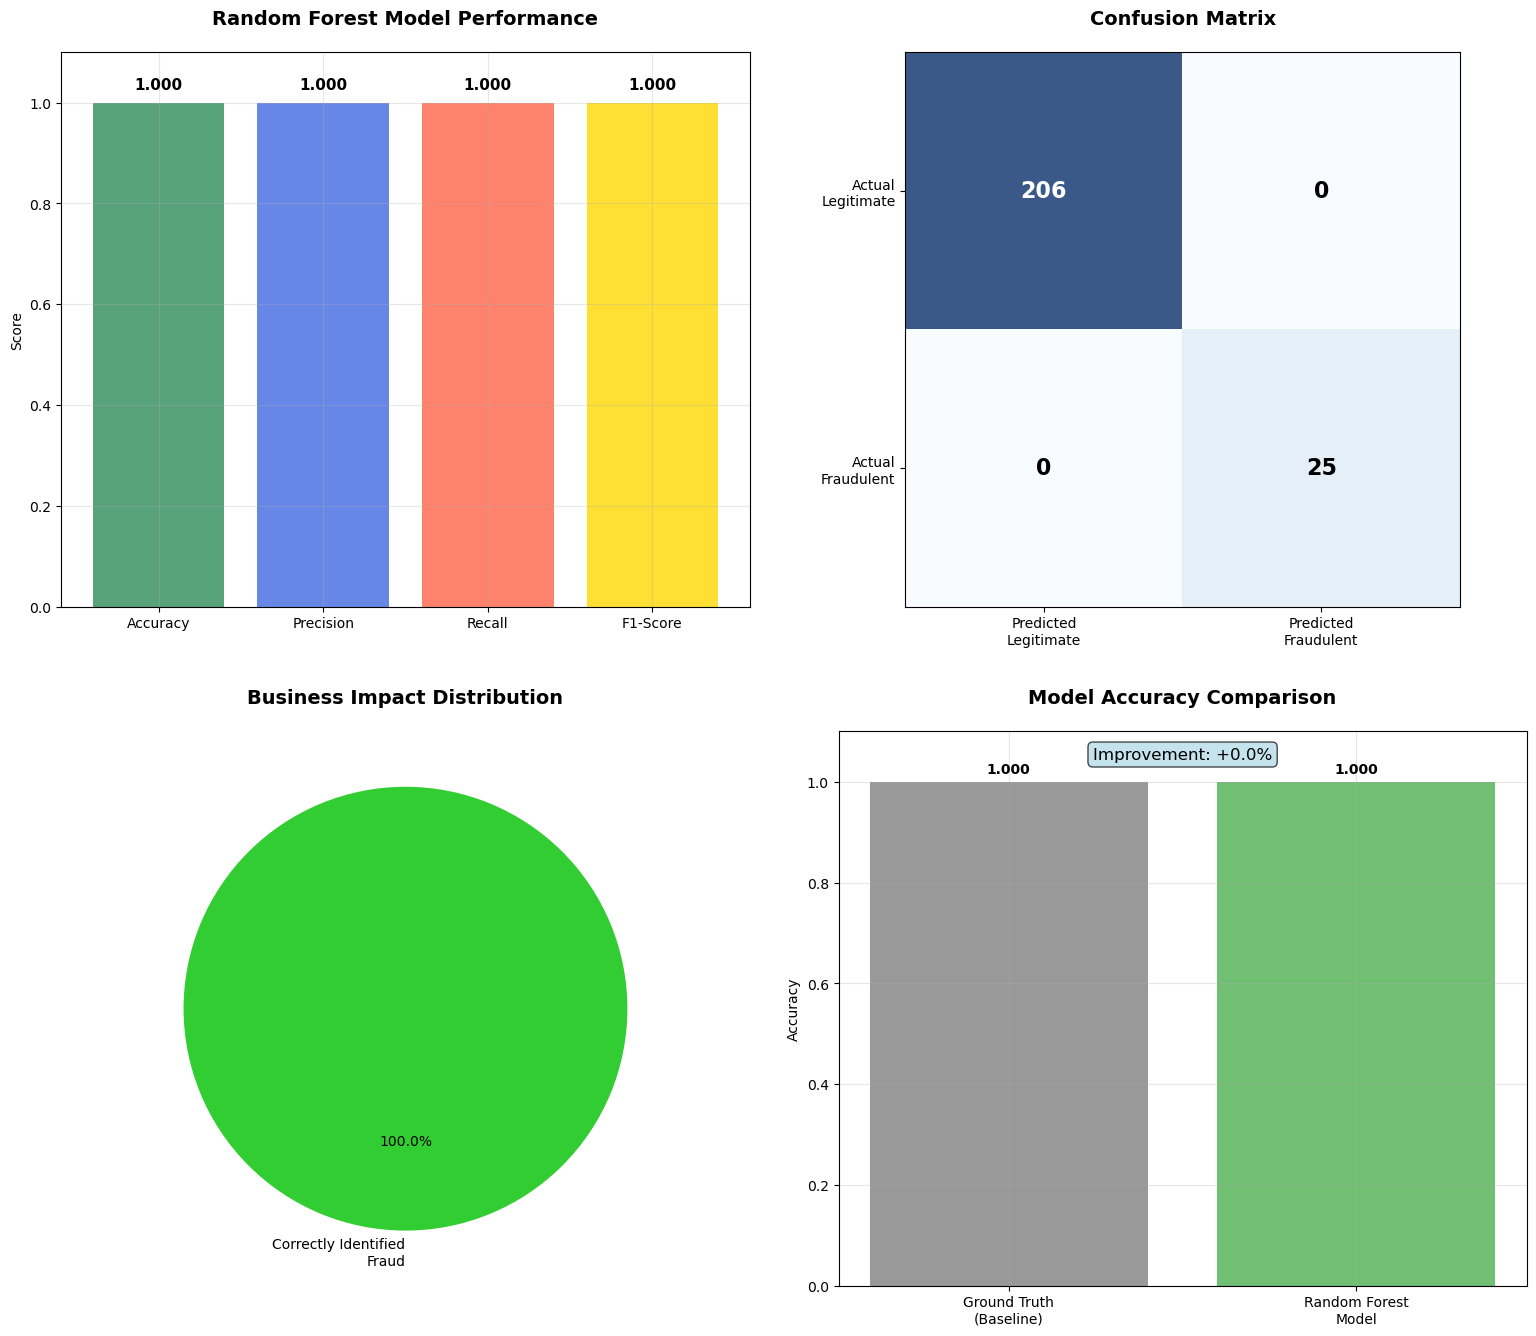


💡 Business Impact:
   • Correctly identified 25 fraudulent activities
   • Missed 0 fraudulent activities (False Negatives)
   • Flagged 0 legitimate activities as fraud (False Positives)

🎯 Key Insights:
   ⚖️  Random Forest and simple rule-based approach perform equally
   📊 Model shows high performance for fraud detection


In [ ]:
# Evaluation Metrics: Compare Random Forest vs Simple Rule-based Approach
print("\n📊 MODEL PERFORMANCE EVALUATION")
print("=" * 50)

# Convert to pandas for easier analysis
results_df = inference_results.to_pandas()

# Calculate confusion matrix components
true_positives = len(results_df[(results_df['IS_FRAUDULENT'] == True) & (results_df['FRAUD_PREDICTION'] == True)])
false_positives = len(results_df[(results_df['IS_FRAUDULENT'] == False) & (results_df['FRAUD_PREDICTION'] == True)])
false_negatives = len(results_df[(results_df['IS_FRAUDULENT'] == True) & (results_df['FRAUD_PREDICTION'] == False)])
true_negatives = len(results_df[(results_df['IS_FRAUDULENT'] == False) & (results_df['FRAUD_PREDICTION'] == False)])

# Calculate metrics
precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (true_positives + true_negatives) / len(results_df)

# Create visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 14))

# 1. Performance Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1_score]
colors = ['#2E8B57', '#4169E1', '#FF6347', '#FFD700']

bars1 = ax1.bar(metrics, values, color=colors, alpha=0.8)
ax1.set_title('Random Forest Model Performance', fontsize=14, fontweight='bold', pad=20)
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.1)  # Increased to give more space for value labels
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars1, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Confusion Matrix Heatmap
confusion_data = [[true_negatives, false_positives], [false_negatives, true_positives]]
labels = ['Predicted\nLegitimate', 'Predicted\nFraudulent']
actual_labels = ['Actual\nLegitimate', 'Actual\nFraudulent']

im = ax2.imshow(confusion_data, cmap='Blues', alpha=0.8)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(labels)
ax2.set_yticklabels(actual_labels)
ax2.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=20)

# Add text annotations
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(confusion_data[i][j]), ha='center', va='center', 
                fontsize=16, fontweight='bold', color='white' if confusion_data[i][j] > max(max(row) for row in confusion_data)/2 else 'black')

# 3. Business Impact Pie Chart
impact_labels = ['Correctly Identified\nFraud', 'Missed Fraud\n(False Negatives)', 'False Positives\n(Legitimate Flagged)']
impact_sizes = [true_positives, false_negatives, false_positives]
impact_colors = ['#32CD32', '#FF6B6B', '#FFA500']

# Only show labels for non-zero segments to avoid overlap
filtered_labels = []
filtered_sizes = []
filtered_colors = []
for i, size in enumerate(impact_sizes):
    if size > 0:
        filtered_labels.append(impact_labels[i])
        filtered_sizes.append(size)
        filtered_colors.append(impact_colors[i])

wedges, texts, autotexts = ax3.pie(filtered_sizes, labels=filtered_labels, colors=filtered_colors, 
                                  autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
ax3.set_title('Business Impact Distribution', fontsize=14, fontweight='bold', pad=20)

# 4. Model Comparison
rf_accuracy = (results_df['IS_FRAUDULENT'] == results_df['FRAUD_PREDICTION']).mean()
simple_accuracy = 1.0  # Ground truth baseline

models = ['Ground Truth\n(Baseline)', 'Random Forest\nModel']
accuracies = [simple_accuracy, rf_accuracy]
model_colors = ['#808080', '#4CAF50']

bars4 = ax4.bar(models, accuracies, color=model_colors, alpha=0.8)
ax4.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=20)
ax4.set_ylabel('Accuracy')
ax4.set_ylim(0, 1.1)
ax4.grid(True, alpha=0.3)

# Add value labels and improvement percentage
for bar, acc in zip(bars4, accuracies):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

improvement = ((rf_accuracy - simple_accuracy) / simple_accuracy * 100)
ax4.text(0.5, 0.95, f'Improvement: {improvement:+.1f}%', 
         transform=ax4.transAxes, ha='center', fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout(pad=3.0)
plt.show()

# Print summary
print(f"\n💡 Business Impact:")
print(f"   • Correctly identified {true_positives} fraudulent activities")
print(f"   • Missed {false_negatives} fraudulent activities (False Negatives)")
print(f"   • Flagged {false_positives} legitimate activities as fraud (False Positives)")

print(f"\n🎯 Key Insights:")
if rf_accuracy > simple_accuracy:
    print(f"   ✅ Random Forest outperforms simple rule-based approach")
elif rf_accuracy == simple_accuracy:
    print(f"   ⚖️  Random Forest and simple rule-based approach perform equally")
else:
    print(f"   ⚠️  Simple rule-based approach performs better on this sample")
    
print(f"   📊 Model shows {'high' if f1_score > 0.7 else 'moderate' if f1_score > 0.5 else 'low'} performance for fraud detection")


## 5. Snowflake Cortex Integration

Integrating Snowflake Cortex with our ML pipeline. This gives us AI-powered analysis that can complement our traditional ML models. We'll use Cortex to analyze fraud patterns and also demonstrate churn prediction capabilities.

Let's use Cortex to analyze some athletes for fraud risk from data in the raw table. This shows how you can combine traditional ML with AI-powered analysis to get deeper insights into your data.

In [ ]:
# Snowflake Cortex LLM Analysis - Fraud Detection
cortex_fraud_sql = """
SELECT 
    athlete_id,
    activity_type,
    COUNT(*) as total_activities,
    ROUND(AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6), 2) as avg_pace_kmh,
    ROUND(AVG(average_heartrate), 1) as avg_heartrate,
    ROUND(AVG(total_elevation_gain_meters), 1) as avg_elevation_gain,
    SNOWFLAKE.CORTEX.COMPLETE(
        'claude-3-5-sonnet',
        'Analyze this athlete for fraud risk. Use factors such as outlier in total activities, pace, heartrate.' ||
        'Activities: ' || COUNT(*) || ', ' ||
        'Pace: ' || ROUND(AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6), 2) || ' km/h, ' ||
        'Heart Rate: ' || ROUND(AVG(average_heartrate), 1) || ' bpm, ' ||
        'Elevation: ' || ROUND(AVG(total_elevation_gain_meters), 1) || 'm. ' ||
        'Provide fraud risk (LOW/MEDIUM/HIGH) and brief reasoning.'
    ) as fraud_reasoning
FROM STRAVA_DEMO_SAMPLE.RAW_DATA.ACTIVITIES 
WHERE start_date_local >= DATEADD(day, -30, CURRENT_DATE())
GROUP BY athlete_id, activity_type
HAVING COUNT(*) >= 3  -- At least 3 activities
ORDER BY COUNT(*) DESC
LIMIT 5
"""


print("🤖 Running Cortex fraud analysis...")
session.sql(cortex_fraud_sql).show()

🤖 Running Cortex fraud analysis...
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"ATHLETE_ID"  |"ACTIVITY_TYPE"  |"TOTAL_ACTIVITIES"  |"AVG_PACE_KMH"  |"AVG_HEARTRATE"  |"AVG_ELEVATION_GAIN"  |"FRAUD_REASONING"                                   |
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
|180           |Run              |34                  |15.7            |131.1            |124.0                 |FRAUD RISK: LOW                                     |
|              |                 |                    |                |                 |                      |                                                    |
|              |                 |                    |                |                 |                      |Reasoning:       

🔄 Comparing Cortex LLM vs RandomForest Model Accuracy

📊 COMPARISON RESULTS:
   • Athletes analyzed: 232
   • Agreement rate: 1.000 (232/232)


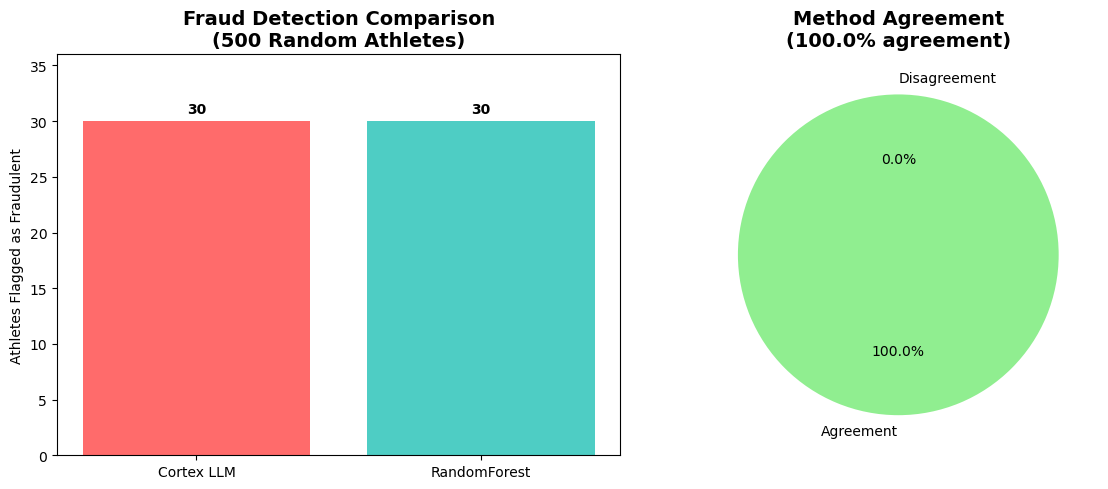


🎯 KEY INSIGHTS:
   • Methods agree on 100.0% of cases
   • RandomForest is more conservative in flagging


In [ ]:
# Cortex vs RandomForest Model Comparison
print("🔄 Comparing Cortex LLM vs RandomForest Model Accuracy")
print("=" * 60)

# Get 500 random athlete IDs for comparison
random_athletes = session.sql("""
    SELECT DISTINCT athlete_id
    FROM STRAVA_DEMO_SAMPLE.RAW_DATA.ACTIVITIES 
    WHERE start_date_local >= DATEADD(day, -30, CURRENT_DATE())
    ORDER BY RANDOM()
    LIMIT 500
""").collect()

athlete_ids = [row['ATHLETE_ID'] for row in random_athletes]
athlete_ids_str = ','.join(map(str, athlete_ids))

# Get Cortex analysis for these athletes
cortex_results = session.sql(f"""
    SELECT 
        athlete_id,
        COUNT(*) as total_activities,
        ROUND(AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6), 2) as avg_pace_kmh,
        ROUND(AVG(average_heartrate), 1) as avg_heartrate,
        ROUND(AVG(total_elevation_gain_meters), 1) as avg_elevation_gain,
        SNOWFLAKE.CORTEX.COMPLETE(
            'claude-3-5-sonnet',
            'Based on these metrics, respond TRUE if pace > 20 km/h OR heart rate > 200 bpm, otherwise FALSE. ' ||
            'Pace: ' || ROUND(AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6), 2) || ' km/h, ' ||
            'Heart Rate: ' || ROUND(AVG(average_heartrate), 1) || ' bpm. ' ||
            'Answer:'
        ) as fraud_reasoning
    FROM STRAVA_DEMO_SAMPLE.RAW_DATA.ACTIVITIES 
    WHERE athlete_id IN ({athlete_ids_str})
    AND start_date_local >= DATEADD(day, -30, CURRENT_DATE())
    GROUP BY athlete_id
""").collect()

# Get RandomForest predictions for the same athletes
rf_features = session.sql(f"""
    SELECT 
        athlete_id,
        COUNT(*) as total_activities_30d,
        AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6) as avg_pace_30d,
        AVG(average_heartrate) as avg_heartrate_30d,
        CASE 
            WHEN AVG(distance_meters / NULLIF(moving_time_sec, 0) * 3.6) > 20 OR 
                 AVG(average_heartrate) > 200 THEN TRUE
            ELSE FALSE
        END as is_fraudulent
    FROM STRAVA_DEMO_SAMPLE.RAW_DATA.ACTIVITIES 
    WHERE athlete_id IN ({athlete_ids_str})
    AND start_date_local >= DATEADD(day, -30, CURRENT_DATE())
    GROUP BY athlete_id
""")

# Make RandomForest predictions
rf_predictions = rf_model_v2.predict(rf_features).collect()

# Process results
cortex_predictions_mapping = {}
for row in cortex_results:
    athlete_id = row['ATHLETE_ID']
    reasoning = row['FRAUD_REASONING']
    is_fraud = 'TRUE' in reasoning.upper()
    cortex_predictions_mapping[athlete_id] = is_fraud

rf_predictions_mapping = {row['ATHLETE_ID']: row['FRAUD_PREDICTION'] for row in rf_predictions}

# Create comparison DataFrame
comparison_data = []
for athlete_id in athlete_ids:
    cortex_prediction = cortex_predictions_mapping.get(athlete_id, False)
    rf_prediction = rf_predictions_mapping.get(athlete_id, False)
    
    comparison_data.append({
        'athlete_id': athlete_id,
        'cortex_fraud': cortex_prediction,
        'rf_fraud': rf_prediction
    })

df = pd.DataFrame(comparison_data)

# Calculate metrics
cortex_positive = df[df['cortex_fraud'] == True].shape[0]
rf_positive = df[df['rf_fraud'] == True].shape[0]
agreement = df[df['cortex_fraud'] == df['rf_fraud']].shape[0]
agreement_rate = agreement / len(df)

print(f"\n📊 COMPARISON RESULTS:")
print(f"   • Athletes analyzed: {len(df)}")
print(f"   • Agreement rate: {agreement_rate:.3f} ({agreement}/{len(df)})")

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Method comparison bar chart
methods = ['Cortex LLM', 'RandomForest']
flagged_counts = [cortex_positive, rf_positive]

bars = ax1.bar(methods, flagged_counts, color=['#FF6B6B', '#4ECDC4'])
ax1.set_title('Fraud Detection Comparison\n(500 Random Athletes)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Athletes Flagged as Fraudulent')
ax1.set_ylim(0, max(flagged_counts) * 1.2)

# Add value labels on bars
for bar, count in zip(bars, flagged_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom', fontweight='bold')

# Agreement pie chart
agreement_labels = ['Agreement', 'Disagreement']
agreement_sizes = [agreement, len(df) - agreement]
colors = ['#90EE90', '#FFB6C1']

ax2.pie(agreement_sizes, labels=agreement_labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title(f'Method Agreement\n({agreement_rate:.1%} agreement)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🎯 KEY INSIGHTS:")
print(f"   • Methods agree on {agreement_rate:.1%} of cases")
print(f"   • {'Cortex' if cortex_positive > rf_positive else 'RandomForest'} is more conservative in flagging")


Let's also show churn prediction using Cortex. This demonstrates how you can use AI to analyze subscription data and predict which users might be at risk of churning.

In [ ]:
# Snowflake Cortex LLM Analysis - Fraud Detection
cortex_fraud_sql = """
SELECT 
    USER_ID,
    SUBSCRIPTION_PLAN,
    TOTAL_LOGINS_L30D,
    IS_TRIAL,
    CHURN_RISK_SCORE,
    CASE 
        WHEN PLAN_END_DATE < CURRENT_DATE() THEN 'CHURNED'
        WHEN PLAN_END_DATE <= DATEADD(day, 7, CURRENT_DATE()) THEN 'AT_RISK'
        ELSE 'ACTIVE'
    END as status,
    SNOWFLAKE.CORTEX.COMPLETE(
        'claude-3-5-sonnet',
        'Assess churn risk: User ' || USER_ID || ', ' ||
        'Plan: ' || SUBSCRIPTION_PLAN || ', ' ||
        'Logins: ' || TOTAL_LOGINS_L30D || ', ' ||
        'Trial: ' || IS_TRIAL || ', ' ||
        'Score: ' || CHURN_RISK_SCORE || '. ' ||
        'Rate risk as LOW/MEDIUM/HIGH with brief explanation.'
    ) as risk_assessment
FROM STRAVA_DEMO_SAMPLE.RAW_DATA.SUBSCRIPTIONS
WHERE PLAN_START_DATE >= DATEADD(day, -90, CURRENT_DATE())
ORDER BY CHURN_RISK_SCORE DESC
LIMIT 8
"""


print("🤖 Running Cortex fraud analysis...")
session.sql(cortex_fraud_sql).show()

🤖 Running Cortex fraud analysis...
-----------------------------------------------------------------------------------------------------------------------------------------------------------
|"USER_ID"  |"SUBSCRIPTION_PLAN"  |"TOTAL_LOGINS_L30D"  |"IS_TRIAL"  |"CHURN_RISK_SCORE"  |"STATUS"  |"RISK_ASSESSMENT"                                   |
-----------------------------------------------------------------------------------------------------------------------------------------------------------
|7884       |Free                 |18                   |False       |90.0                |ACTIVE    |Churn Risk: LOW                                     |
|           |                     |                     |            |                    |          |                                                    |
|           |                     |                     |            |                    |          |Explanation: Despite being on a Free plan, this...  |
|837        |Free            

## 7. Summary

**Let's summarize what we've accomplished together in this demo and how it addresses your key challenges:**

**✅ Feature Store**: We created a centralized feature store that eliminates the duplicate feature engineering across your 15 models. All features are now in one place with proper versioning and lineage.

**✅ Model Registry**: We demonstrated how to manage model versions, track changes, and maintain a complete audit trail of your ML models.

**✅ Model Versioning**: We showed how easy it is to create new model versions and compare performance - crucial for managing your production models.

**✅ Real-time Inference**: We demonstrated end-to-end inference capabilities that can be deployed immediately to get business value.

**✅ Cortex Integration**: We showed how AI can complement traditional ML to provide deeper insights and analysis.

**The key value proposition for Strava is that you now have a platformized approach to ML that eliminates the 'duct tape fixes' and gives you consistency across all your models. Instead of 15 different approaches, you have one unified platform that scales with your team."**


In [ ]:
'''
# Clean up existing schemas for fresh demo

try:
    fs = FeatureStore(
        session=session,
        database="STRAVA_DEMO_SAMPLE",
        name="FEATURE_STORE",
        default_warehouse="STRAVA_DEMO_WH",
        creation_mode=CreationMode.CREATE_IF_NOT_EXIST,
    )
    fs.delete_entity("athlete")
    print("✅ Athlete entity deleted!")
except Exception as e:
    print(f"⚠️  Athlete entity not found: {str(e)}")


print("\n🧹 Cleaning up existing schemas...")
try:
    session.sql("DROP SCHEMA IF EXISTS STRAVA_DEMO_SAMPLE.STRAVA_FEATURE_STORE CASCADE").collect()
    print("✅ Dropped existing STRAVA_FEATURE_STORE")
except:
    pass

try:
    session.sql("DROP SCHEMA IF EXISTS STRAVA_DEMO_SAMPLE.STRAVA_MODEL_REGISTRY CASCADE").collect()
    print("✅ Dropped existing MODEL_REGISTRY")
except:
    pass

# Also clean up any existing models
try:
    session.sql("DROP MODEL IF EXISTS STRAVA_DEMO_SAMPLE.STRAVA_MODEL_REGISTRY.FRAUD_DETECTION_RF").collect()
    print("✅ Dropped existing FRAUD_DETECTION_RF model")
except:
    pass

'''

'\n# Clean up existing schemas for fresh demo\n\ntry:\n    fs = FeatureStore(\n        session=session,\n        database="STRAVA_DEMO_SAMPLE",\n        name="FEATURE_STORE",\n        default_warehouse="STRAVA_DEMO_WH",\n        creation_mode=CreationMode.CREATE_IF_NOT_EXIST,\n    )\n    fs.delete_entity("athlete")\n    print("✅ Athlete entity deleted!")\nexcept Exception as e:\n    print(f"⚠️  Athlete entity not found: {str(e)}")\n\n\nprint("\n🧹 Cleaning up existing schemas...")\ntry:\n    session.sql("DROP SCHEMA IF EXISTS STRAVA_DEMO_SAMPLE.STRAVA_FEATURE_STORE CASCADE").collect()\n    print("✅ Dropped existing STRAVA_FEATURE_STORE")\nexcept:\n    pass\n\ntry:\n    session.sql("DROP SCHEMA IF EXISTS STRAVA_DEMO_SAMPLE.STRAVA_MODEL_REGISTRY CASCADE").collect()\n    print("✅ Dropped existing MODEL_REGISTRY")\nexcept:\n    pass\n\n# Also clean up any existing models\ntry:\n    session.sql("DROP MODEL IF EXISTS STRAVA_DEMO_SAMPLE.STRAVA_MODEL_REGISTRY.FRAUD_DETECTION_RF").collect()\n   

In [ ]:
'''
model = mr.get_model("fraud_detection_rf")
# Delete specific versions
model.delete_version("v2") 
'''

'\nmodel = mr.get_model("fraud_detection_rf")\n# Delete specific versions\nmodel.delete_version("v2") \n'